### Imports y DataSets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb
import shap
from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")
test  = pd.read_csv("../data/test.csv")

FEATURE_COLS = joblib.load("../model/feature_cols.pkl")
TARGET_COL   = "total_delivery_min"

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Train: 6517 | Val: 1769 | Test: 1714


In [2]:
def evaluate(y_true, y_low, y_high, label=""):
    within = ((y_true >= y_low) & (y_true <= y_high)).mean()
    late   = (y_true > y_high).mean()
    early  = (y_true < y_low).mean()
    width  = (y_high - y_low).mean()

    print(f"{label}")
    print(f"  Coverage rate:   {within*100:.1f}%")
    print(f"  Late rate:       {late*100:.1f}%   (llegaron después del promise_end, OBJETIVO 3%)")
    print(f"  Early rate:      {early*100:.1f}%  (llegaron antes del promise_start)")
    print(f"  Avg window:      {width:.1f} min")

    return {"coverage": within, "late": late, "early": early, "width": width}

In [3]:
TAU_LOW  = 0.15
TAU_HIGH = 0.97 # 3% llega tarde

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

### Modelos iniciales

In [4]:
lr_low  = QuantileRegressor(quantile=TAU_LOW,  alpha=0.1, solver="highs")
lr_high = QuantileRegressor(quantile=TAU_HIGH, alpha=0.1, solver="highs")

lr_low.fit(X_train_sc,  y_train)
lr_high.fit(X_train_sc, y_train)

val_low_lr  = lr_low.predict(X_val_sc)
val_high_lr = lr_high.predict(X_val_sc)

metrics_lr_val = evaluate(y_val, val_low_lr, val_high_lr, "Lineal - Validación")

Lineal - Validación
  Coverage rate:   81.8%
  Late rate:       3.1%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      15.1%  (llegaron antes del promise_start)
  Avg window:      53.1 min


In [5]:
xgb_params = {
    "objective":      "reg:quantileerror",
    "n_estimators":   500,
    "learning_rate":  0.05,
    "max_depth":      4,
    "random_state":   42,
}

xgb_low  = xgb.XGBRegressor(**xgb_params, quantile_alpha=TAU_LOW)
xgb_high = xgb.XGBRegressor(**xgb_params, quantile_alpha=TAU_HIGH)

xgb_low.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)
xgb_high.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_low_xgb  = xgb_low.predict(X_val)
val_high_xgb = xgb_high.predict(X_val)

metrics_xgb_val = evaluate(y_val, val_low_xgb, val_high_xgb, "XGBoost - Validación")


[0]	validation_0-quantile:3.07795


[100]	validation_0-quantile:1.91627
[200]	validation_0-quantile:1.90774
[300]	validation_0-quantile:1.90877
[400]	validation_0-quantile:1.91389
[499]	validation_0-quantile:1.91432
[0]	validation_0-quantile:1.65243
[100]	validation_0-quantile:1.12055
[200]	validation_0-quantile:1.11097
[300]	validation_0-quantile:1.11325
[400]	validation_0-quantile:1.12218
[499]	validation_0-quantile:1.13219
XGBoost - Validación
  Coverage rate:   78.7%
  Late rate:       4.7%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      16.6%  (llegaron antes del promise_start)
  Avg window:      31.9 min


xgb_high tiene pérdida en la validación pasando los 100 árboles, voy a volver a armarlo con early stop

In [6]:
xgb_params = {
    "objective":      "reg:quantileerror",
    "n_estimators":   500,
    "learning_rate":  0.05,
    "max_depth":      4,
    "random_state":   42,
}

xgb_low  = xgb.XGBRegressor(**xgb_params, quantile_alpha=TAU_LOW)
xgb_high = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=20, quantile_alpha=TAU_HIGH)

xgb_low.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)
xgb_high.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_low_xgb  = xgb_low.predict(X_val)
val_high_xgb = xgb_high.predict(X_val)

metrics_xgb_val = evaluate(y_val, val_low_xgb, val_high_xgb, "XGBoost - Validación")


[0]	validation_0-quantile:3.07795


[100]	validation_0-quantile:1.91627
[200]	validation_0-quantile:1.90774
[300]	validation_0-quantile:1.90877
[400]	validation_0-quantile:1.91389
[499]	validation_0-quantile:1.91432
[0]	validation_0-quantile:1.65243
[100]	validation_0-quantile:1.12055
[153]	validation_0-quantile:1.11039
XGBoost - Validación
  Coverage rate:   79.7%
  Late rate:       3.7%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      16.6%  (llegaron antes del promise_start)
  Avg window:      33.4 min


         coverage   late  early   width
Lineal      0.818  0.031  0.151  53.085
XGBoost     0.797  0.037  0.166  33.367


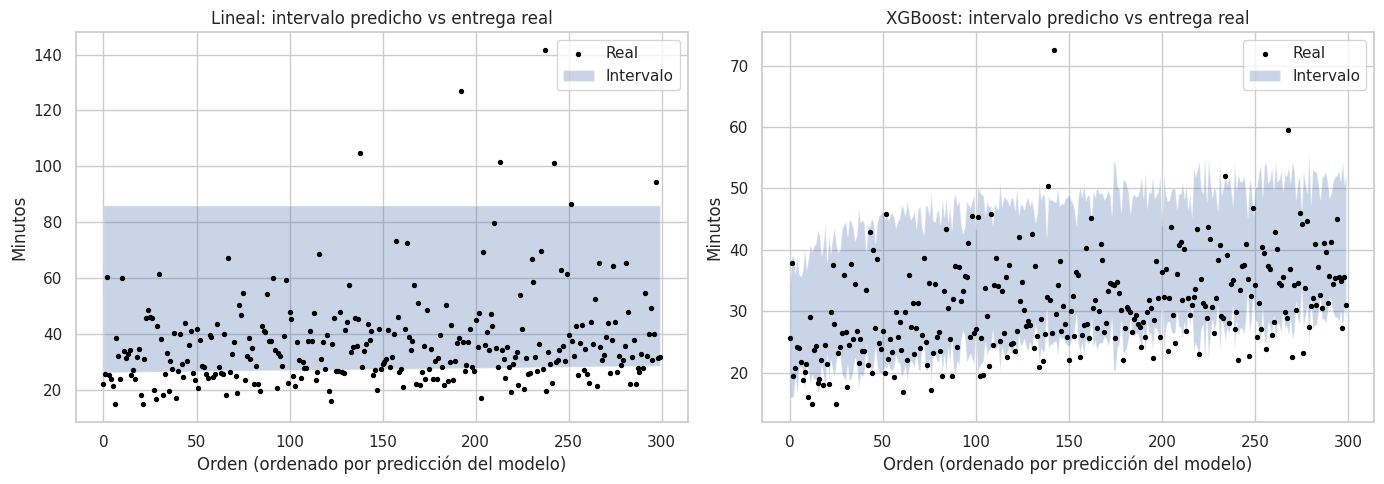

In [7]:
comparison = pd.DataFrame({
    "Lineal":   metrics_lr_val,
    "XGBoost":  metrics_xgb_val,
}).T.round(3)

print(comparison)

# Visualización de los intervalos predichos vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (low, high, label) in zip(axes, [
    (val_low_lr,  val_high_lr,  "Lineal"),
    (val_low_xgb, val_high_xgb, "XGBoost"),
]):
    # Ordenar por el punto medio predicho de cada modelo
    midpoint = (low + high) / 2
    idx = np.argsort(midpoint)[:300]

    ax.scatter(range(300), y_val.values[idx], s=8, color="black", label="Real", zorder=3)
    ax.fill_between(range(300), low[idx], high[idx], alpha=0.3, label="Intervalo")
    ax.set_title(f"{label}: intervalo predicho vs entrega real")
    ax.set_xlabel("Orden (ordenado por predicción del modelo)")
    ax.set_ylabel("Minutos")
    ax.legend()

plt.tight_layout()
plt.show()

El modelo lineal muestra una línea horizontal en ~85 minutos, esto es porque la señal para el 3% es muy exigente, si reducimos esto a 15% de las entregas llegan tarde tenemos...

In [8]:
TAU_LOW  = 0.15
TAU_HIGH_2 = 0.85 # 15% llega tarde

lr_low  = QuantileRegressor(quantile=TAU_LOW,  alpha=0.1, solver="highs")
lr_high = QuantileRegressor(quantile=TAU_HIGH_2, alpha=0.1, solver="highs")

lr_low.fit(X_train_sc,  y_train)
lr_high.fit(X_train_sc, y_train)

val_low_lr  = lr_low.predict(X_val_sc)
val_high_lr = lr_high.predict(X_val_sc)

metrics_lr_val = evaluate(y_val, val_low_lr, val_high_lr, "Lineal - Validación")

Lineal - Validación
  Coverage rate:   70.6%
  Late rate:       14.3%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      15.1%  (llegaron antes del promise_start)
  Avg window:      28.5 min


         coverage   late  early   width
Lineal      0.706  0.143  0.151  28.530
XGBoost     0.797  0.037  0.166  33.367


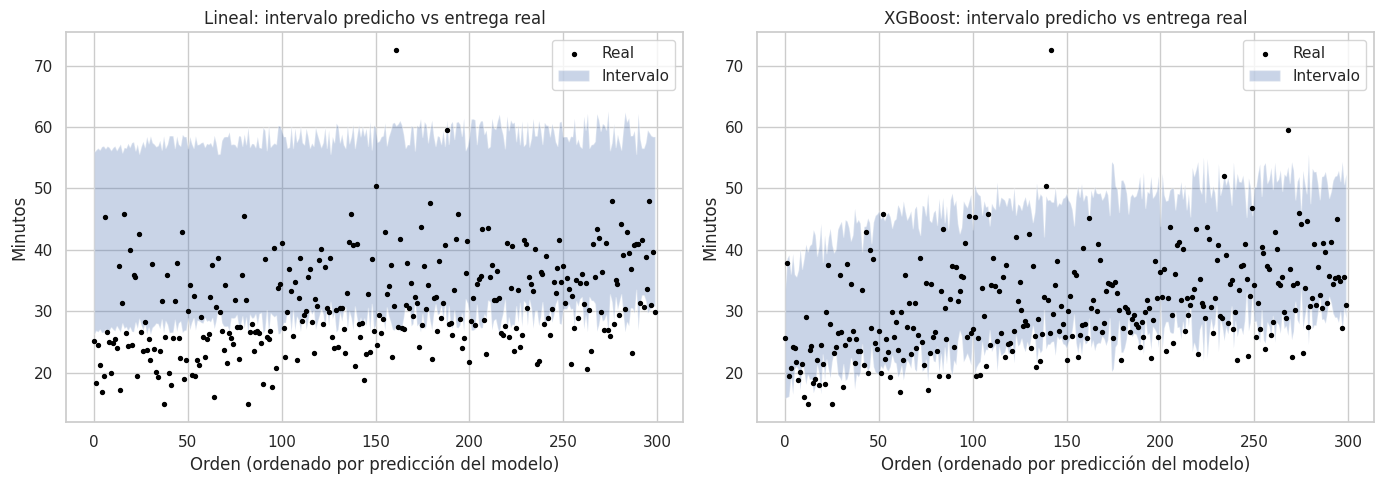

In [9]:
comparison = pd.DataFrame({
    "Lineal":   metrics_lr_val,
    "XGBoost":  metrics_xgb_val,
}).T.round(3)

print(comparison)

# Visualización de los intervalos predichos vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (low, high, label) in zip(axes, [
    (val_low_lr,  val_high_lr,  "Lineal"),
    (val_low_xgb, val_high_xgb, "XGBoost"),
]):
    # Ordenar por el punto medio predicho de cada modelo
    midpoint = (low + high) / 2
    idx = np.argsort(midpoint)[:300]

    ax.scatter(range(300), y_val.values[idx], s=8, color="black", label="Real", zorder=3)
    ax.fill_between(range(300), low[idx], high[idx], alpha=0.3, label="Intervalo")
    ax.set_title(f"{label}: intervalo predicho vs entrega real")
    ax.set_xlabel("Orden (ordenado por predicción del modelo)")
    ax.set_ylabel("Minutos")
    ax.legend()

plt.tight_layout()
plt.show()

Ventanas más cerruchadas, en ~55 minutos. Sin embargo XGBoost sigue performando mejor, y con ~3.7% de tardías en validation.

### Hyperparameter tuning

Ahora hagámos un poco de hyperparameter tuning en XGBoost. Solo lo vamos a hacer para xgb_high, ya que el low ya está alrededor de 15%, que es el valor que busco en principio.

In [10]:
# Dejo n_estimators = 1500 por el early stop.
# Voy a probar distintos TAU_HIGH a ver si logramos llegar al target de 3% de Late Rate
# manteniendo lo mejor posible la ventana promedio.
TAU_HIGH_LIST = [0.97, 0.9725, 0.975]
lr_list = [0.001, 0.003, 0.005, 0.007, 0.01, 0.05, 0.1]

for TAU_HIGH in TAU_HIGH_LIST:
    print()
    print(f"{'='*50}")
    print(f"  TAU_HIGH = {TAU_HIGH}")
    print(f"{'='*50}")

    for lr in lr_list:
        xgb_params = {
            "objective":      "reg:quantileerror",
            "n_estimators":   1500,
            "learning_rate":  lr,
            "max_depth":      4,
            "random_state":   42,
        }

        xgb_high = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=20, quantile_alpha=TAU_HIGH)

        xgb_high.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose = 1500 # Conservo una versión de verbose para chequear convergencia
        )

        val_high_xgb = xgb_high.predict(X_val)
        late  = (y_val > val_high_xgb).mean()
        width = (val_high_xgb - val_low_xgb).mean()

        print(f"  lr={lr}  Late Rate: {late*100:.1f}%  Avg window: {width:.1f} min")
        print()
        print()


  TAU_HIGH = 0.97
[0]	validation_0-quantile:1.68110


[1499]	validation_0-quantile:1.23498
  lr=0.001  Late Rate: 2.8%  Avg window: 39.5 min


[0]	validation_0-quantile:1.67989
[1499]	validation_0-quantile:1.13766
  lr=0.003  Late Rate: 3.3%  Avg window: 34.3 min


[0]	validation_0-quantile:1.67868
[1058]	validation_0-quantile:1.14183
  lr=0.005  Late Rate: 3.5%  Avg window: 34.1 min


[0]	validation_0-quantile:1.67749
[839]	validation_0-quantile:1.12879
  lr=0.007  Late Rate: 3.6%  Avg window: 33.7 min


[0]	validation_0-quantile:1.67573
[694]	validation_0-quantile:1.12363
  lr=0.01  Late Rate: 3.6%  Avg window: 33.4 min


[0]	validation_0-quantile:1.65243
[154]	validation_0-quantile:1.11041
  lr=0.05  Late Rate: 3.7%  Avg window: 33.4 min


[0]	validation_0-quantile:1.62481
[96]	validation_0-quantile:1.11031
  lr=0.1  Late Rate: 4.1%  Avg window: 33.1 min



  TAU_HIGH = 0.9725
[0]	validation_0-quantile:1.58290
[1499]	validation_0-quantile:1.16294
  lr=0.001  Late Rate: 2.5%  Avg window: 40.5 min


[0]	validation_0-quantile:1.58169
[149

Con 641 iteraciones TAU=0.975, lr=0.01 converge en 3.0% de Late Rate, solo agregando 2 minutos a la ventana promedio. Como llegamos al target, no realizo más hyperparameter tuning en la depth.

In [11]:
best_xgb_high = xgb.XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=0.975,
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=4,
    early_stopping_rounds=20,
    random_state=42,
)
best_xgb_high.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=20,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1500, n_jobs=None,
             num_parallel_tree=None, objective='reg:quantileerror', ...)

In [12]:
window_val = val_high_xgb - val_low_xgb

print("Distribución de anchos de ventana (validación):")
print(f"  Min:    {window_val.min():.1f} min")
print(f"  P25:    {np.percentile(window_val, 25):.1f} min")
print(f"  Median: {np.median(window_val):.1f} min")
print(f"  P75:    {np.percentile(window_val, 75):.1f} min")
print(f"  P90:    {np.percentile(window_val, 90):.1f} min")
print(f"  P95:    {np.percentile(window_val, 95):.1f} min")
print(f"  P99:    {np.percentile(window_val, 99):.1f} min")
print(f"  Max:    {window_val.max():.1f} min")
print()
print(f"  % de órdenes con ventana > 60 min: {(window_val > 60).mean()*100:.1f}%")
print(f"  % de órdenes con ventana > 45 min: {(window_val > 45).mean()*100:.1f}%")
print(f"  % de órdenes con ventana > 30 min: {(window_val > 30).mean()*100:.1f}%")

Distribución de anchos de ventana (validación):
  Min:    12.4 min
  P25:    25.2 min
  Median: 33.3 min
  P75:    43.6 min
  P90:    50.4 min
  P95:    56.3 min
  P99:    62.5 min
  Max:    72.0 min

  % de órdenes con ventana > 60 min: 2.0%
  % de órdenes con ventana > 45 min: 21.1%
  % de órdenes con ventana > 30 min: 59.8%


Si negocio prioriza ventanas más angostas, se puede reducir el cuantil bajo
(TAU_LOW) o aplicar un MAX_WINDOW en post-processing: `y_pred_low = y_pred_high - MAX_WINDOW`

Esto conserva el late rate (y_pred_high no cambia) a costa de aumentar
el early rate (más órdenes llegarían antes del promise_start).


### SHAP

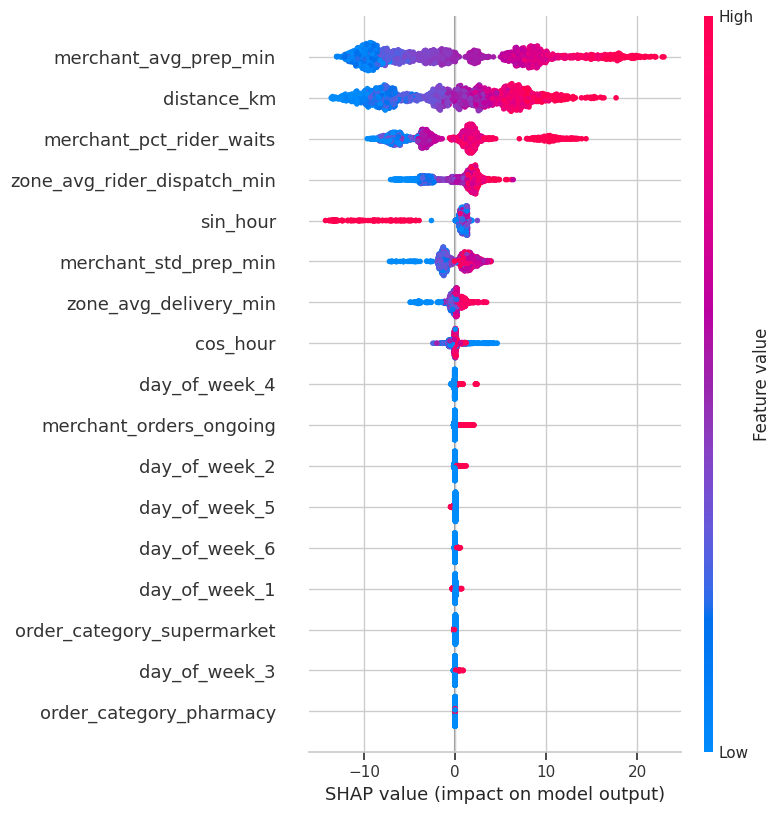

In [13]:
# Uso el modelo del cuantil alto porque es el que determina el late rate.
explainer  = shap.TreeExplainer(best_xgb_high)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(
    shap_values,
    X_val,
    feature_names=FEATURE_COLS,
    show=True,
)

Las dos variables más importantes son los principales drivers de entrega que esperábamos, con merchant_avg_prep_min y distance_km dominandp el modelo.

sin_hour captura el efecto de demanda horaria.
Categoría y día de semana tienen impacto marginal.

Lo que más me preocupa, sin embargo, es el impacto de `merchant_pct_rider_waits` en el modelo final. Ya que se trata de una variable binaria en la que definimos que si el rider estuvo en la locación más de 2 minutos este tuvo que esperar a que el comercio termine con el pedido. En primera instancia, no parece que debería tener más fuerza que el `merchant_std_prep_min`.

Voy a probar sacar `merchant_pct_rider_waits` del entrenamiento del modelo para checkear si cambia mucho la Avg window o el Late Rate.

In [14]:
# Reentrenar sin merchant_pct_rider_waits
feature_cols_reduced = [f for f in FEATURE_COLS if f != "merchant_pct_rider_waits"]

xgb_high_reduced = xgb.XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=0.975,
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=4,
    early_stopping_rounds=20,
    random_state=42,
)
xgb_high_reduced.fit(
    X_train[feature_cols_reduced], y_train,
    eval_set=[(X_val[feature_cols_reduced], y_val)],
    verbose=500
)

xgb_low_reduced = xgb.XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=TAU_LOW,
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=4,
    early_stopping_rounds=20,
    random_state=42,
)
xgb_low_reduced.fit(
    X_train[feature_cols_reduced], y_train,
    eval_set=[(X_val[feature_cols_reduced], y_val)],
    verbose=False
)

val_low_xgb  = xgb_low_reduced.predict(X_val[feature_cols_reduced])
val_high_xgb = xgb_high_reduced.predict(X_val[feature_cols_reduced])

metrics_xgb_val = evaluate(y_val, val_low_xgb, val_high_xgb, "XGBoost - Validación")

[0]	validation_0-quantile:1.47428


[500]	validation_0-quantile:1.02825
[604]	validation_0-quantile:1.02532
XGBoost - Validación
  Coverage rate:   81.4%
  Late rate:       2.9%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      15.7%  (llegaron antes del promise_start)
  Avg window:      36.5 min


Me quedo con la versión sin esta variable, ya que el Late Rate no se ve muy afectado y el Avg Window crece en un minuto.

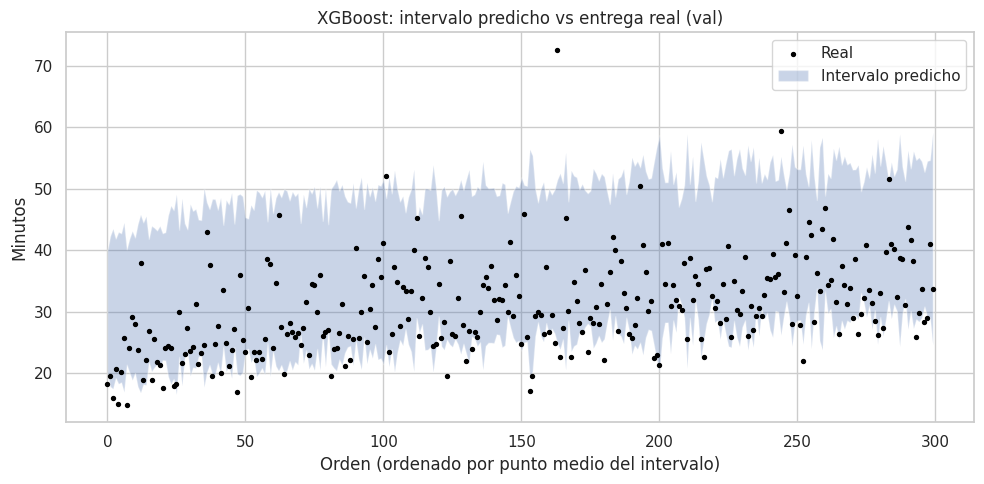

In [15]:
midpoint = (val_low_xgb + val_high_xgb) / 2
idx = np.argsort(midpoint)[:300]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(range(300), y_val.values[idx], s=8, color="black", label="Real", zorder=3)
ax.fill_between(range(300), val_low_xgb[idx], val_high_xgb[idx], alpha=0.3, label="Intervalo predicho")
ax.set_title("XGBoost: intervalo predicho vs entrega real (val)")
ax.set_xlabel("Orden (ordenado por punto medio del intervalo)")
ax.set_ylabel("Minutos")
ax.legend()
plt.tight_layout()
plt.show()

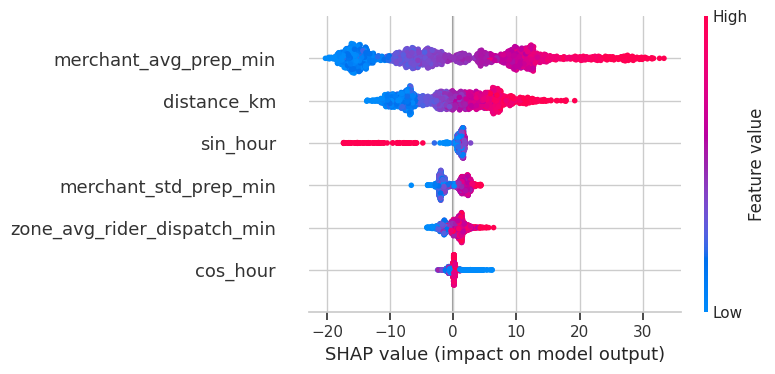

In [18]:
features_a_mostrar = [
    'merchant_avg_prep_min',
    'distance_km',
    'sin_hour',
    'merchant_std_prep_min',
    'zone_avg_rider_dispatch_min',
    'cos_hour',
]

idx_cols = [X_val[feature_cols_reduced].columns.tolist().index(f) for f in features_a_mostrar]

explainer   = shap.TreeExplainer(xgb_high_reduced)
shap_values = explainer.shap_values(X_val[feature_cols_reduced])

shap.summary_plot(
    shap_values[:, idx_cols],
    X_val[feature_cols_reduced].iloc[:, idx_cols],
    feature_names=features_a_mostrar,
    show=True,
)

In [19]:
X_test_r = X_test[feature_cols_reduced]

test_high = xgb_high_reduced.predict(X_test_r)
test_low  = xgb_low_reduced.predict(X_test_r)

evaluate(y_test, test_low, test_high, "XGBoost Final - Test Set")

XGBoost Final - Test Set
  Coverage rate:   79.4%
  Late rate:       2.7%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      17.9%  (llegaron antes del promise_start)
  Avg window:      36.4 min


{'coverage': 0.794049008168028,
 'late': 0.027421236872812137,
 'early': 0.17852975495915985,
 'width': 36.408463}

El test final da resultados acordes a lo esperado.

### Guardamos los modelos y el nuevo feature set

In [20]:
joblib.dump(xgb_high_reduced,      "../model/xgb_high.pkl")
joblib.dump(xgb_low_reduced,  "../model/xgb_low.pkl")
joblib.dump(feature_cols_reduced, "../model/feature_cols.pkl")

['../model/feature_cols.pkl']